# 🏠 House Price Prediction

## End-to-End Machine Learning Web Application

### Author

Andrew Asem

### Technologies

- Python
- Pandas
- NumPy
- Scikit-learn
- FastAPI
- React
- TypeScript

---

## Project Overview

This project aims to develop an end-to-end machine learning web application that predicts house prices based on property features.

The project includes:

- Data Exploration
- Data Cleaning
- Feature Engineering
- Model Training
- Model Evaluation
- FastAPI Backend
- React Frontend

The final solution will allow users to enter house information through a web interface and receive an estimated house price using the best-performing regression model.

# 1. Business Problem

Accurately estimating house prices is important for buyers, sellers, and real estate agencies.

Manual estimation is often subjective and time-consuming. Machine learning models can analyze historical housing data and learn relationships between property features and market prices, providing faster and more consistent price estimates.

# 2. Project Objectives

The objectives of this project are:

- Explore and understand the dataset.
- Clean and preprocess the data.
- Perform feature engineering.
- Train multiple regression models.
- Compare model performance.
- Select the best model.
- Build a FastAPI prediction API.
- Develop a React frontend for predictions.

# 3. Import Libraries

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plots
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

# 4. Load Dataset

In this section, we load the dataset into a pandas DataFrame and verify that it has been loaded correctly by displaying its dimensions and the first few rows.

In [2]:
# Load the dataset
df = pd.read_csv("data/house_prices.csv")

# Display dataset shape
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# Display first 5 rows
df.head()

Rows: 187531
Columns: 21


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


# 5. Dataset Information

Understanding the dataset structure is the first step in any machine learning project.

We inspect:

- Number of rows and columns
- Data types
- Missing values
- Memory usage

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

# 6. Statistical Summary

The statistical summary provides an overview of the numerical features, including:

- Count
- Mean
- Standard Deviation
- Minimum
- Quartiles
- Maximum

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Index,187531.0,93765.000000,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Price (in rupees),169866.0,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
Dimensions,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Plot Area,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 7. Missing Values

Before building any model, we check whether the dataset contains missing values that need to be handled.

In [6]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

Plot Area      187531
Dimensions     187531
Society        109678
Super Area     107685
Car Parking    103357
                ...  
Description      3023
Furnishing       2897
Bathroom          828
Status            615
Transaction        83
Length: 17, dtype: int64

# 8. Duplicate Records

Duplicate records can negatively affect model performance. We check whether duplicate rows exist in the dataset.

In [8]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


# 9. Dataset Columns

Display all feature names before beginning exploratory data analysis.

In [9]:
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

1. Index
2. Title
3. Description
4. Amount(in rupees)
5. Price (in rupees)
6. location
7. Carpet Area
8. Status
9. Floor
10. Transaction
11. Furnishing
12. facing
13. overlooking
14. Society
15. Bathroom
16. Balcony
17. Car Parking
18. Ownership
19. Super Area
20. Dimensions
21. Plot Area


# 10. Data Dictionary

The following table summarizes the dataset columns, their data types, the percentage of missing values, and a brief description of their purpose in the project.

This helps us identify which features are useful, which require preprocessing, and which may need to be removed.

In [12]:
data_dictionary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum(),
    "Missing (%)": (df.isnull().mean() * 100).round(2)
})

data_dictionary.reset_index(drop=True, inplace=True)

data_dictionary

,Column,Data Type,Missing Values,Missing (%)
0,Index,int64,0,0.00
1,Title,str,0,0.00
2,Description,str,3023,1.61
3,Amount(in rupees),str,0,0.00
4,Price (in rupees),float64,17665,9.42
...,...,...,...,...
16,Car Parking,str,103357,55.11
17,Ownership,str,65517,34.94
18,Super Area,str,107685,57.42
19,Dimensions,float64,187531,100.00


# 11. Feature Classification

Each feature is classified according to its role in the machine learning pipeline.

In [13]:
feature_info = pd.DataFrame({
    "Feature": df.columns,
    "Role": [
        "Identifier",          # Index
        "Text",
        "Text",
        "Target",
        "Numeric Feature",
        "Categorical",
        "Text Numeric",
        "Categorical",
        "Text Numeric",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Text Numeric",
        "Text Numeric",
        "Categorical",
        "Categorical",
        "Text Numeric",
        "Drop",
        "Drop"
    ]
})

feature_info

,Feature,Role
0,Index,Identifier
1,Title,Text
2,Description,Text
3,Amount(in rupees),Target
4,Price (in rupees),Numeric Feature
...,...,...
16,Car Parking,Categorical
17,Ownership,Categorical
18,Super Area,Text Numeric
19,Dimensions,Drop


# 12. Feature Engineering - Target Variable

The target variable (`Amount(in rupees)`) is stored as text using Indian numbering units such as **Lac** and **Cr**.

Before training a regression model, these values must be converted into numeric values representing the total price in Indian Rupees (INR).

Examples:

- 42 Lac → 4,200,000
- 1.40 Cr → 14,000,000

In [14]:
def convert_price(price):
    """
    Convert prices stored as text (e.g., '42 Lac', '1.40 Cr')
    into numeric values in Indian Rupees.
    """

    if pd.isna(price):
        return np.nan

    price = str(price).strip()

    if "Cr" in price:
        return float(price.replace("Cr", "").strip()) * 10_000_000

    elif "Lac" in price:
        return float(price.replace("Lac", "").strip()) * 100_000

    else:
        try:
            return float(price)
        except:
            return np.nan

## Apply the Conversion

Create a new numeric target column while preserving the original text column for reference.

In [15]:
df["Price_INR"] = df["Amount(in rupees)"].apply(convert_price)

df[["Amount(in rupees)", "Price_INR"]].head(10)

,Amount(in rupees),Price_INR
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0
5,45 Lac,4500000.0
6,16.5 Lac,1650000.0
7,60 Lac,6000000.0
8,60 Lac,6000000.0
9,1.60 Cr,16000000.0


## Validate the Conversion

Verify that the conversion was performed correctly by checking summary statistics and sample values.

In [16]:
df["Price_INR"].describe()

count    1.778470e+05
mean     1.198134e+07
std      3.943827e+07
min      1.000000e+05
25%      4.840000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: Price_INR, dtype: float64

# 13. Validate the Target Variable

Before training any machine learning model, it is important to inspect the target variable for unusual or extreme values.

Outliers may represent:

- Luxury properties
- Data entry errors
- Incorrect unit conversions

We investigate these values before deciding how to handle them.

In [17]:
# Display the 10 most expensive properties

df.sort_values("Price_INR", ascending=False)[
    [
        "Amount(in rupees)",
        "Price_INR",
        "Title",
        "location"
    ]
].head(10)

,Amount(in rupees),Price_INR,Title,location
181234,1400.30 Cr,1.400300e+10,3 BHK Ready to Occupy Flat for sale in Nest Ha...,vadodara
176536,510.04 Cr,5.100400e+09,3 BHK Ready to Occupy Flat for sale Hill Cart ...,siliguri
174894,396.75 Cr,3.967500e+09,2 BHK Ready to Occupy Flat for sale Kachna Road,raipur
175013,229.80 Cr,2.298000e+09,2 BHK Ready to Occupy Flat for sale in Chaitan...,raipur
183303,80 Cr,8.000000e+08,Studio Apartment for sale Awleshpur chitaipur...,varanasi
51966,60 Cr,6.000000e+08,5 BHK Ready to Occupy Flat for sale in DLF The...,gurgaon
52058,55 Cr,5.500000e+08,4 BHK Ready to Occupy Flat for sale in DLF Cam...,gurgaon
50321,55 Cr,5.500000e+08,5 BHK Ready to Occupy Flat for sale in DLF The...,gurgaon
52387,52 Cr,5.200000e+08,5 BHK Ready to Occupy Flat for sale in DLF Cam...,gurgaon
51965,50 Cr,5.000000e+08,5 BHK Ready to Occupy Flat for sale Golf Cours...,gurgaon


# 14. Distribution of the Target Variable

Visualizing the target variable helps us understand:

- Distribution shape
- Presence of skewness
- Potential outliers

This information guides future preprocessing decisions.

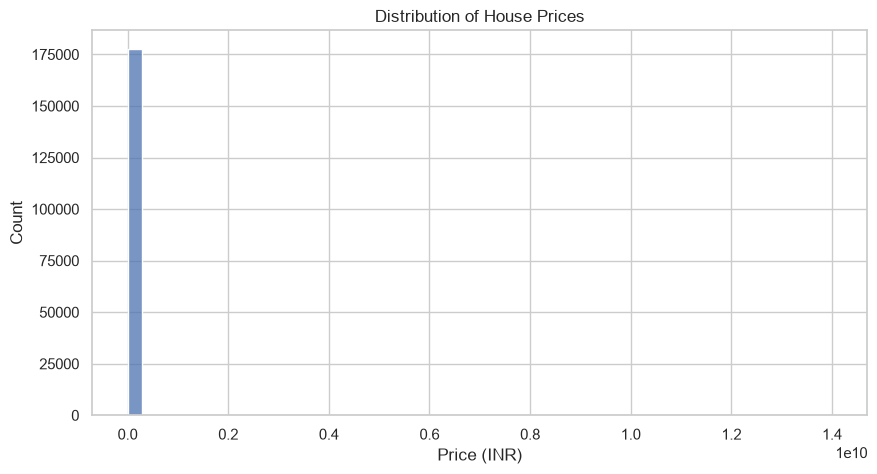

In [18]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Price_INR"], bins=50)

plt.title("Distribution of House Prices")
plt.xlabel("Price (INR)")
plt.ylabel("Count")

plt.show()

# 15. Boxplot of the Target Variable

A boxplot provides a compact summary of the target variable and highlights potential outliers.

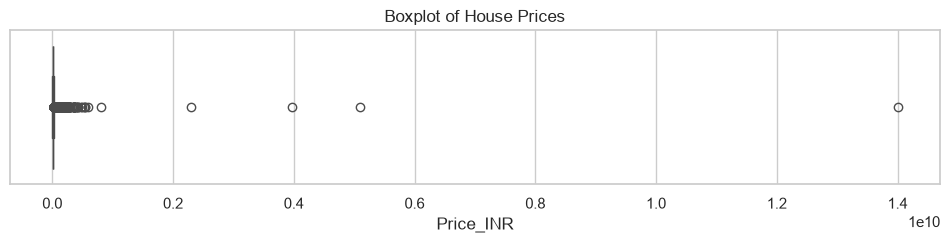

In [19]:
plt.figure(figsize=(12, 2))

sns.boxplot(x=df["Price_INR"])

plt.title("Boxplot of House Prices")

plt.show()

# 16. Log Transformation of the Target Variable

The house prices are highly right-skewed because a small number of luxury properties have extremely high prices.

To better visualize the distribution, we apply a logarithmic transformation.

The log transformation compresses very large values while preserving the ordering of the data, making the distribution easier to analyze.

In [20]:
df["Log_Price"] = np.log1p(df["Price_INR"])

## Distribution After Log Transformation

The following histogram shows the distribution after applying the logarithmic transformation.

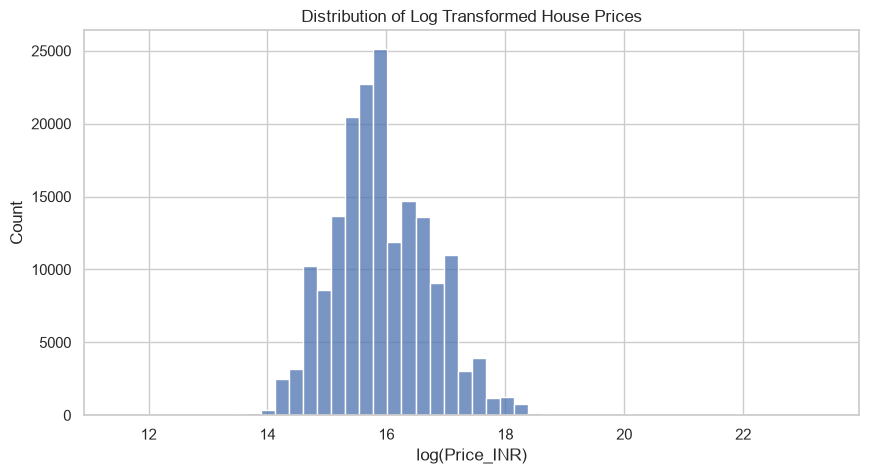

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(df["Log_Price"], bins=50)

plt.title("Distribution of Log Transformed House Prices")

plt.xlabel("log(Price_INR)")

plt.ylabel("Count")

plt.show()

## Boxplot After Log Transformation

The boxplot after logarithmic transformation provides a clearer visualization of the spread of the data.

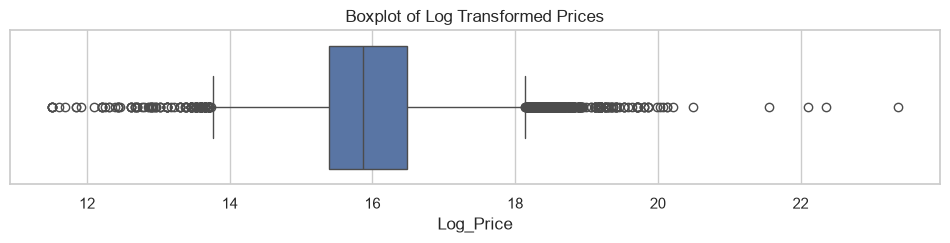

In [22]:
plt.figure(figsize=(12,2))

sns.boxplot(x=df["Log_Price"])

plt.title("Boxplot of Log Transformed Prices")

plt.show()

# 17. Observations

### Original Target Variable (`Price_INR`)

- The target variable was successfully converted from text (Lac/Cr) into numeric values (INR).
- The original distribution is highly right-skewed.
- Several extremely expensive properties produce significant outliers.
- These outliers compress the histogram, making the distribution difficult to interpret.

### Log-Transformed Target Variable (`Log_Price`)

- The logarithmic transformation significantly reduces the skewness.
- The distribution becomes much closer to a normal (bell-shaped) distribution.
- Outliers are still present but have much less influence on the visualization.
- Log transformation may improve the performance of regression models such as Linear Regression, Ridge, and Lasso.

### Conclusion

For exploratory analysis, the logarithmic transformation provides a much clearer view of the data distribution. During model development, we will compare models trained on both the original target and the log-transformed target to determine which produces better prediction accuracy.

# 18. Feature Engineering - Carpet Area

The `Carpet Area` feature represents the usable floor area of a property.

Since the values are stored as text (e.g., `500 sqft`), they must be converted into numeric values before they can be used in machine learning models.

A new column named `Carpet_Area_sqft` will be created while preserving the original feature.

In [23]:
def extract_carpet_area(area):
    """
    Extract the numeric value from the Carpet Area column.
    Example:
        '500 sqft' -> 500
    """

    if pd.isna(area):
        return np.nan

    area = str(area).lower().replace(",", "").strip()

    try:
        return float(area.replace("sqft", "").strip())
    except:
        return np.nan

## Apply the Transformation

Convert the textual carpet area into a numeric feature measured in square feet.

In [24]:
df["Carpet_Area_sqft"] = df["Carpet Area"].apply(extract_carpet_area)

df[
    [
        "Carpet Area",
        "Carpet_Area_sqft"
    ]
].head(10)

,Carpet Area,Carpet_Area_sqft
0,500 sqft,500.0
1,473 sqft,473.0
2,779 sqft,779.0
3,530 sqft,530.0
4,635 sqft,635.0
5,NaN,NaN
6,550 sqft,550.0
7,NaN,NaN
8,NaN,NaN
9,900 sqft,900.0


## Validate the Transformation

Display summary statistics for the newly engineered feature.

In [25]:
df["Carpet_Area_sqft"].describe()

count    100428.000000
mean       1268.525909
std        3129.311735
min           1.000000
25%         801.000000
50%        1071.000000
75%        1500.000000
max      709222.000000
Name: Carpet_Area_sqft, dtype: float64

## Check Missing Values

Measure how many missing values remain after the conversion.

In [26]:
missing = df["Carpet_Area_sqft"].isna().sum()

percentage = (missing / len(df)) * 100

print(f"Missing values : {missing:,}")
print(f"Missing (%)    : {percentage:.2f}%")

Missing values : 87,103
Missing (%)    : 46.45%


# 19. Carpet Area Observations

Summarize the results obtained after converting the Carpet Area feature.

In [27]:
print(f"Minimum Area : {df['Carpet_Area_sqft'].min()} sqft")
print(f"Maximum Area : {df['Carpet_Area_sqft'].max()} sqft")
print(f"Average Area : {df['Carpet_Area_sqft'].mean():.2f} sqft")

Minimum Area : 1.0 sqft
Maximum Area : 709222.0 sqft
Average Area : 1268.53 sqft


# 20. Investigating Suspicious Carpet Area Values

The summary statistics revealed extremely small and extremely large carpet area values.

Before removing or modifying any records, these observations are investigated to determine whether they are valid properties or potential data quality issues.

In [28]:
# Smallest carpet areas

df.sort_values("Carpet_Area_sqft")[
    [
        "Title",
        "Carpet Area",
        "Carpet_Area_sqft",
        "Amount(in rupees)",
        "location"
    ]
].head(10)

,Title,Carpet Area,Carpet_Area_sqft,Amount(in rupees),location
176967,2 BHK Ready to Occupy Flat for sale in The New...,1 sqft,1.0,25 Lac,sonipat
147727,3 BHK Ready to Occupy Flat for sale in Saptris...,1 sqft,1.0,Call for Price,agra
185837,3 BHK Ready to Occupy Flat for sale Madhurawada,1 sqft,1.0,70 Lac,visakhapatnam
172072,2 BHK Ready to Occupy Flat for sale in Yesh Fa...,1 sqft,1.0,35 Lac,mysore
148158,3 BHK Ready to Occupy Flat for sale George Town,2 sqft,2.0,68 Lac,allahabad
169827,3 BHK Ready to Occupy Flat for sale in Inland ...,5 sqft,5.0,2.2 Lac,mangalore
183490,2 BHK Ready to Occupy Flat for sale orderly ba...,12 sqft,12.0,35 Lac,varanasi
151038,4 BHK Ready to Occupy Flat for sale in Exotic ...,17 sqft,17.0,1.47 Cr,chandigarh
185376,2 BHK Ready to Occupy Flat for sale Pithapuram...,20 sqft,20.0,45 Lac,visakhapatnam
184633,2 BHK Ready to Occupy Flat for sale in Honeyy ...,20 sqft,20.0,47 Lac,visakhapatnam


## Largest Carpet Areas

Display the largest recorded carpet areas to inspect possible outliers.

In [29]:
df.sort_values("Carpet_Area_sqft", ascending=False)[
    [
        "Title",
        "Carpet Area",
        "Carpet_Area_sqft",
        "Amount(in rupees)",
        "location"
    ]
].head(10)

,Title,Carpet Area,Carpet_Area_sqft,Amount(in rupees),location
165733,2 BHK Ready to Occupy Flat for sale Kahilipara,709222 sqft,709222.0,60 Lac,guwahati
149239,2 BHK Ready to Occupy Flat for sale Tapukara,495970 sqft,495970.0,19 Lac,bhiwadi
147580,3 BHK Ready to Occupy Flat for sale Fatehabad ...,282004 sqft,282004.0,20 Lac,agra
50895,3 BHK Ready to Occupy Flat for sale in TARC Ma...,194936 sqft,194936.0,2.60 Cr,gurgaon
147791,3 BHK Ready to Occupy Flat for sale in Aparna ...,113134 sqft,113134.0,56 Lac,agra
82876,3 BHK Ready to Occupy Flat for sale in Seven H...,107806 sqft,107806.0,68 Lac,jaipur
180072,2 BHK Ready to Occupy Flat for sale Velappaya,81845 sqft,81845.0,45 Lac,thrissur
176689,3 BHK Ready to Occupy Flat for sale Sevoke Road,81675 sqft,81675.0,45.7 Lac,siliguri
176690,2 BHK Ready to Occupy Flat for sale Sevoke Road,71775 sqft,71775.0,40.2 Lac,siliguri
176711,2 BHK Ready to Occupy Flat for sale Sevoke Road,71025 sqft,71025.0,39.8 Lac,siliguri


## Distribution of Carpet Area

Visualizing the carpet area helps identify skewness and potential outliers.

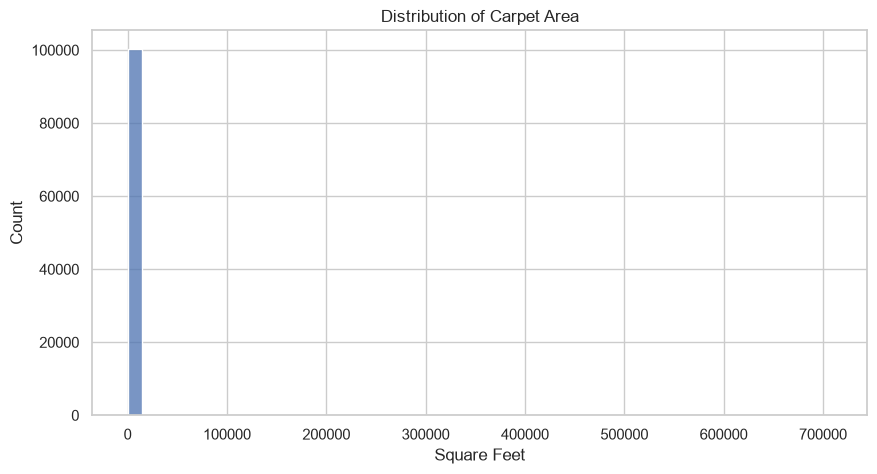

In [30]:
plt.figure(figsize=(10,5))

sns.histplot(df["Carpet_Area_sqft"], bins=50)

plt.title("Distribution of Carpet Area")

plt.xlabel("Square Feet")

plt.ylabel("Count")

plt.show()

## Boxplot of Carpet Area

A boxplot highlights potential outliers in the Carpet Area feature.

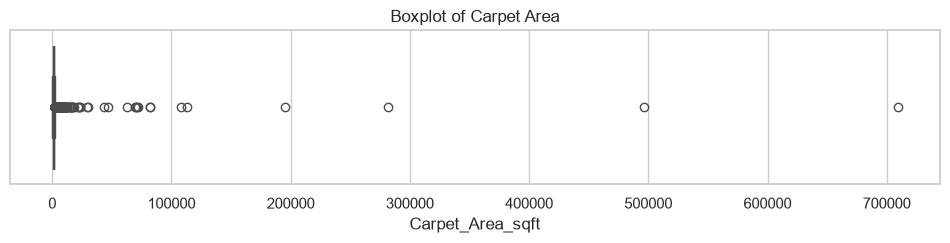

In [31]:
plt.figure(figsize=(12,2))

sns.boxplot(x=df["Carpet_Area_sqft"])

plt.title("Boxplot of Carpet Area")

plt.show()

# 21. Carpet Area Observations

Summarize the findings after inspecting the Carpet Area feature.

Possible points to discuss:

- Missing values
- Distribution
- Extreme values
- Potential data quality issues
- Planned preprocessing strategy

# 22. Carpet Area Percentile Analysis

Before deciding whether to remove extreme values, we analyze the distribution using percentiles.

Percentiles help identify the typical range of property sizes while minimizing the influence of extreme observations.

This approach provides an objective basis for handling outliers.

In [32]:
df["Carpet_Area_sqft"].quantile([
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    0.995,
    0.999
])

0.250     801.0
0.500    1071.0
0.750    1500.0
0.900    1950.0
0.950    2550.0
0.990    4583.0
0.995    4583.0
0.999    5700.0
Name: Carpet_Area_sqft, dtype: float64

# 23. Visualizing Carpet Area (Excluding Extreme Outliers)

To better understand the distribution of typical properties, we temporarily visualize carpet areas below the 99th percentile.

This visualization is used only for exploratory analysis and does not modify the dataset.

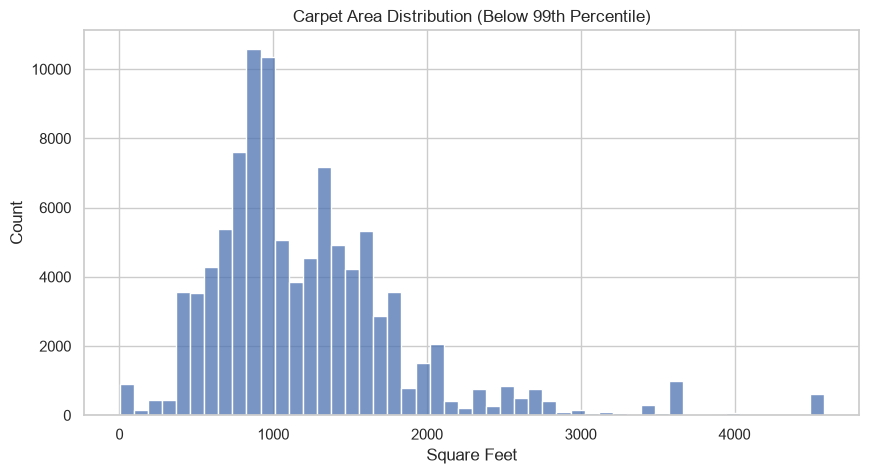

In [33]:
p99 = df["Carpet_Area_sqft"].quantile(0.99)

plt.figure(figsize=(10,5))

sns.histplot(
    df.loc[df["Carpet_Area_sqft"] <= p99, "Carpet_Area_sqft"],
    bins=50
)

plt.title("Carpet Area Distribution (Below 99th Percentile)")
plt.xlabel("Square Feet")
plt.ylabel("Count")

plt.show()

## Boxplot Below the 99th Percentile

The following visualization focuses on the majority of properties after excluding the most extreme observations.

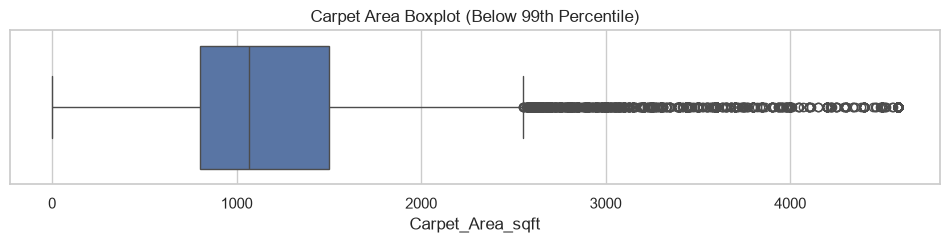

In [34]:
plt.figure(figsize=(12,2))

sns.boxplot(
    x=df.loc[df["Carpet_Area_sqft"] <= p99, "Carpet_Area_sqft"]
)

plt.title("Carpet Area Boxplot (Below 99th Percentile)")

plt.show()

# 24. Observations

Summarize the percentile analysis.

Include:

- Typical carpet area range.
- Whether the extreme values appear realistic.
- Whether percentile-based filtering seems appropriate.
- Any insights from the histogram and boxplot after excluding the top 1%.

# 25. Cleaning Carpet Area

Based on the exploratory analysis:

- Carpet areas smaller than **100 sqft** are considered invalid.
- Carpet areas larger than the **99.9th percentile (5700 sqft)** are considered extreme outliers.

Instead of removing entire records, these values are replaced with missing values (`NaN`).

This preserves the remaining information for each property while preventing unrealistic values from influencing the model.

In [35]:
# Number of invalid values before cleaning

invalid_small = (df["Carpet_Area_sqft"] < 100).sum()

invalid_large = (df["Carpet_Area_sqft"] > 5700).sum()

print(f"Areas < 100 sqft : {invalid_small}")
print(f"Areas > 5700 sqft: {invalid_large}")

Areas < 100 sqft : 905
Areas > 5700 sqft: 99


In [36]:
# Replace unrealistic values with NaN

df.loc[df["Carpet_Area_sqft"] < 100, "Carpet_Area_sqft"] = np.nan

df.loc[df["Carpet_Area_sqft"] > 5700, "Carpet_Area_sqft"] = np.nan

## Validate the Cleaning

After replacing unrealistic values with missing values, verify the updated summary statistics.

In [37]:
df["Carpet_Area_sqft"].describe()

count    99424.000000
mean      1246.987277
std        688.046429
min        100.000000
25%        805.000000
50%       1086.000000
75%       1500.000000
max       5700.000000
Name: Carpet_Area_sqft, dtype: float64

In [38]:
print(f"Missing values : {df['Carpet_Area_sqft'].isna().sum():,}")

print(f"Missing (%) : {df['Carpet_Area_sqft'].isna().mean()*100:.2f}%")

Missing values : 88,107
Missing (%) : 46.98%


# 26. Observations

Summarize the results after cleaning the Carpet Area feature.

Suggested points:

- Invalid values were replaced with missing values.
- Extremely large outliers were removed based on the 99.9th percentile.
- The feature is now more suitable for future preprocessing and model training.

# 27. Feature Engineering - Super Area

The `Super Area` column represents the total built-up area of a property.

Like the Carpet Area feature, it is stored as text and must be converted into a numeric feature before it can be used in machine learning models.

A new column named `Super_Area_sqft` will be created while preserving the original feature.

In [39]:
def extract_super_area(area):
    """
    Extract the numeric value from the Super Area column.

    Example:
        '1200 sqft' -> 1200
    """

    if pd.isna(area):
        return np.nan

    area = str(area).lower().replace(",", "").strip()

    try:
        return float(area.replace("sqft", "").strip())
    except:
        return np.nan

## Apply the Transformation

Convert the textual Super Area values into numeric square feet.

In [40]:
df["Super_Area_sqft"] = df["Super Area"].apply(extract_super_area)

df[
    [
        "Super Area",
        "Super_Area_sqft"
    ]
].head(10)

,Super Area,Super_Area_sqft
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
5,680 sqft,680.0
6,NaN,NaN
7,575 sqft,575.0
8,600 sqft,600.0
9,NaN,NaN


## Validate the Transformation

Generate descriptive statistics for the engineered feature.

In [41]:
df["Super_Area_sqft"].describe()

count    75406.000000
mean      1385.678328
std        749.161278
min          1.000000
25%       1000.000000
50%       1300.000000
75%       1687.000000
max      40000.000000
Name: Super_Area_sqft, dtype: float64

## Check Missing Values

Measure the amount of missing data in the new feature.


In [42]:
missing = df["Super_Area_sqft"].isna().sum()

percentage = missing / len(df) * 100

print(f"Missing values : {missing:,}")
print(f"Missing (%)    : {percentage:.2f}%")

Missing values : 112,125
Missing (%)    : 59.79%


# 28. Investigating Super Area

Inspect the smallest and largest values to identify possible data quality issues before cleaning.

In [43]:
# Smallest values

df.sort_values("Super_Area_sqft")[
    [
        "Title",
        "Super Area",
        "Super_Area_sqft",
        "Amount(in rupees)",
        "location"
    ]
].head(10)

,Title,Super Area,Super_Area_sqft,Amount(in rupees),location
180679,2 BHK Ready to Occupy Flat for sale Fatehpura,1 sqft,1.0,45 Lac,udaipur
180481,3 BHK Ready to Occupy Flat for sale Sreekaryam,12 sqft,12.0,1.44 Cr,trivandrum
166174,1 BHK Ready to Occupy Flat for sale Bhoopatwal...,24 sqft,24.0,10 Lac,haridwar
166172,1 BHK Ready to Occupy Flat for sale Bhoopatwal...,24 sqft,24.0,10 Lac,haridwar
4908,1 BHK Ready to Occupy Flat for sale in Dhara A...,27 sqft,27.0,Call for Price,ahmedabad
143664,"1 BHK Ready to Occupy Flat for sale Sector 93,...",28 sqft,28.0,8 Lac,noida
177240,1 BHK Ready to Occupy Flat for sale Fazilpur V...,29 sqft,29.0,8 Lac,sonipat
5255,1 BHK Ready to Occupy Flat for sale Hathijan,29 sqft,29.0,9 Lac,ahmedabad
148122,1 BHK Ready to Occupy Flat for sale Nasibur ba...,35 sqft,35.0,15 Lac,allahabad
176409,2 BHK Ready to Occupy Flat for sale Kasumpti,38 sqft,38.0,Call for Price,shimla


In [44]:
# Largest values

df.sort_values("Super_Area_sqft", ascending=False)[
    [
        "Title",
        "Super Area",
        "Super_Area_sqft",
        "Amount(in rupees)",
        "location"
    ]
].head(10)

,Title,Super Area,Super_Area_sqft,Amount(in rupees),location
16963,Studio Apartment for sale Halanayakanahalli,"40,000 sqft",40000.0,16 Cr,bangalore
175087,1 BHK Ready to Occupy Flat for sale Sejbahar,"37,952 sqft",37952.0,8 Lac,raipur
17562,> 10 BHK Ready to Occupy Flat for sale Phase 1...,"36,000 sqft",36000.0,12 Cr,bangalore
71001,> 10 BHK Ready to Occupy Flat for sale in Jyot...,"25,000 sqft",25000.0,12 Cr,hyderabad
117232,> 10 BHK Ready to Occupy Flat for sale in Godr...,"25,000 sqft",25000.0,Call for Price,new-delhi
51094,> 10 BHK Ready to Occupy Flat for sale in DLF ...,"20,000 sqft",20000.0,Call for Price,gurgaon
71491,10 BHK Ready to Occupy Flat for sale in Positi...,"20,000 sqft",20000.0,10 Cr,hyderabad
183303,Studio Apartment for sale Awleshpur chitaipur...,"20,000 sqft",20000.0,80 Cr,varanasi
176489,3 BHK Ready to Occupy Flat for sale hakimpara ...,"18,000 sqft",18000.0,75 Lac,siliguri
2314,> 10 BHK Ready to Occupy Flat for sale in LIVA...,"15,000 sqft",15000.0,36 Cr,mumbai


# 29. Visualizing Super Area

Visualize the distribution of the engineered feature.

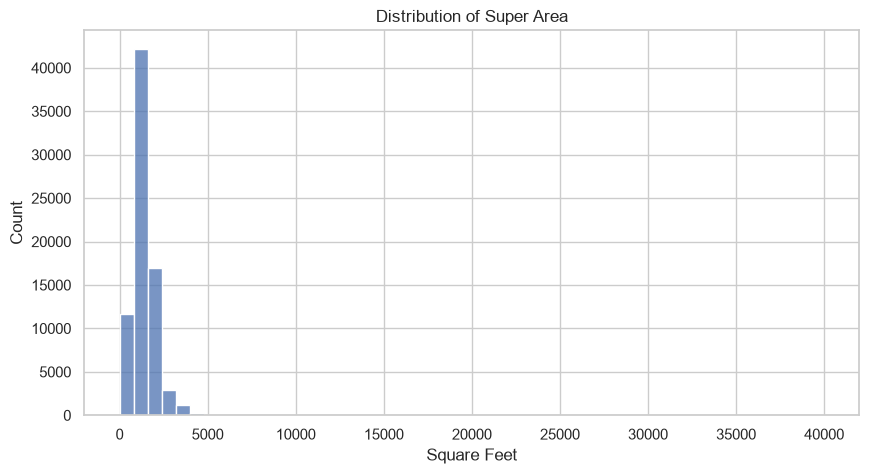

In [45]:
plt.figure(figsize=(10,5))

sns.histplot(df["Super_Area_sqft"], bins=50)

plt.title("Distribution of Super Area")

plt.xlabel("Square Feet")

plt.ylabel("Count")

plt.show()

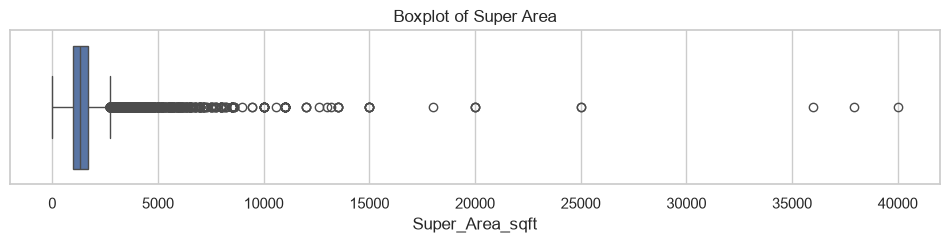

In [46]:
plt.figure(figsize=(12,2))

sns.boxplot(x=df["Super_Area_sqft"])

plt.title("Boxplot of Super Area")

plt.show()

# 30. Cleaning Super Area

The extracted Super Area feature contains some impossible values.

Examples such as 1 sqft, 12 sqft and 24 sqft are clearly invalid.

Properties smaller than 100 sqft are removed.

Large properties are kept because luxury villas and estates can legitimately exceed 10,000 square feet.

In [47]:
# Remove impossible Super Area values

df.loc[df["Super_Area_sqft"] < 100, "Super_Area_sqft"] = np.nan

print("Remaining values:")
print(df["Super_Area_sqft"].describe())

print()
print("Missing values :", df["Super_Area_sqft"].isna().sum())
print(
    "Missing (%) :",
    round(df["Super_Area_sqft"].isna().mean() * 100, 2),
    "%"
)

Remaining values:
count    75362.000000
mean      1386.451912
std        748.695089
min        100.000000
25%       1000.000000
50%       1300.000000
75%       1689.750000
max      40000.000000
Name: Super_Area_sqft, dtype: float64

Missing values : 112169
Missing (%) : 59.81 %


### 31.Observation

- Invalid Super Area values smaller than 100 sqft were identified as data entry errors and replaced with missing values.

- Extremely large properties were retained because luxury villas, estates, and commercial-style residential buildings can legitimately have very large built-up areas.

- After cleaning, the minimum valid Super Area became 100 sqft.

- The feature still contains approximately 60% missing values, which will be addressed later during the preprocessing and feature engineering stages.

# 32. Cleaning Bathroom Feature

The Bathroom column is stored as text and contains missing values.

The objective of this step is to:

- Convert the values into numeric format.
- Detect invalid entries.
- Understand the distribution.
- Prepare the feature for future preprocessing.

In [48]:
# Display sample values

df["Bathroom"].head(10)

0    1
1    2
2    2
3    1
4    2
5    1
6    1
7    1
8    1
9    3
Name: Bathroom, dtype: str

### Converting Bathroom to Numeric

In [49]:
# Convert Bathroom into numeric

df["Bathroom"] = pd.to_numeric(df["Bathroom"], errors="coerce")

print(df["Bathroom"].describe())

print()

print("Missing values :", df["Bathroom"].isna().sum())
print(
    "Missing (%) :",
    round(df["Bathroom"].isna().mean() * 100, 2),
    "%"
)

count    186668.000000
mean          2.426640
std           0.863244
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          10.000000
Name: Bathroom, dtype: float64

Missing values : 863
Missing (%) : 0.46 %


### Bathroom Distribution

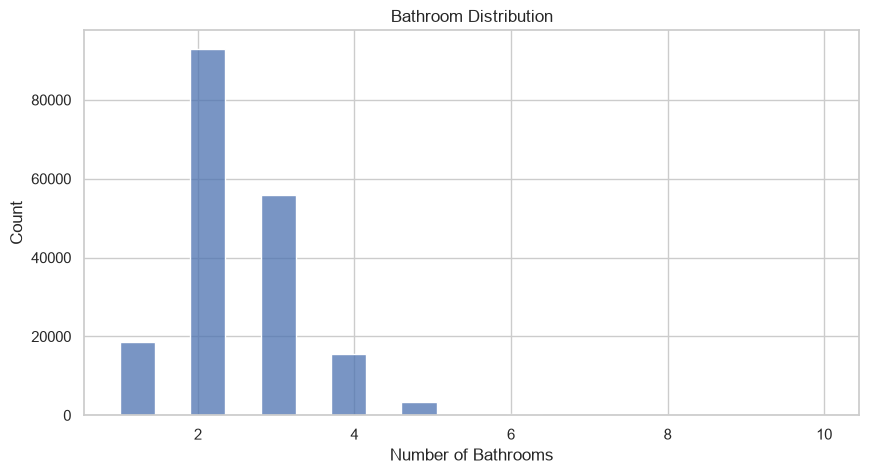

In [50]:
plt.figure(figsize=(10,5))

sns.histplot(df["Bathroom"], bins=20)

plt.title("Bathroom Distribution")

plt.xlabel("Number of Bathrooms")

plt.ylabel("Count")

plt.show()

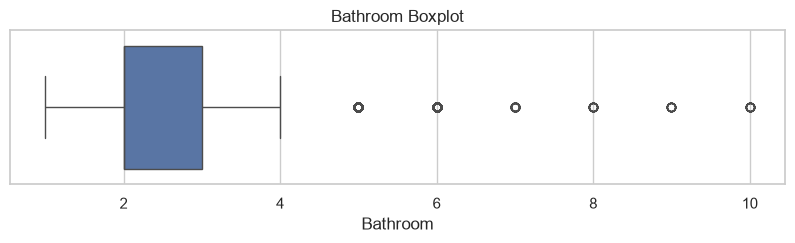

In [51]:
plt.figure(figsize=(10,2))

sns.boxplot(x=df["Bathroom"])

plt.title("Bathroom Boxplot")

plt.show()

In [52]:
# Frequency table

df["Bathroom"].value_counts().sort_index()

Bathroom
1.0     18654
2.0     93007
3.0     55781
4.0     15600
5.0      3343
6.0       209
7.0        35
8.0        14
9.0        11
10.0       14
Name: count, dtype: int64

In [53]:
# Smallest values

df.nsmallest(
    10,
    "Bathroom"
)[
    [
        "Title",
        "Bathroom",
        "Amount(in rupees)",
        "location"
    ]
]

,Title,Bathroom,Amount(in rupees),location
0,1 BHK Ready to Occupy Flat for sale in Srushti...,1.0,42 Lac,thane
3,1 BHK Ready to Occupy Flat for sale Kasheli,1.0,25 Lac,thane
5,1 BHK Ready to Occupy Flat for sale in Virat A...,1.0,45 Lac,thane
6,1 BHK Ready to Occupy Flat for sale Mumbra,1.0,16.5 Lac,thane
7,1 BHK Ready to Occupy Flat for sale Kalwa,1.0,60 Lac,thane
8,1 BHK Ready to Occupy Flat for sale Kalwa,1.0,60 Lac,thane
14,1 BHK Ready to Occupy Flat for sale Rabodi,1.0,75 Lac,thane
16,1 BHK Ready to Occupy Flat for sale in Green W...,1.0,37 Lac,thane
17,1 BHK Ready to Occupy Flat for sale Dombivli West,1.0,35 Lac,thane
19,1 BHK Ready to Occupy Flat for sale Shahad,1.0,35 Lac,thane


In [54]:
# Largest values

df.nlargest(
    10,
    "Bathroom"
)[
    [
        "Title",
        "Bathroom",
        "Amount(in rupees)",
        "location"
    ]
]

,Title,Bathroom,Amount(in rupees),location
538,6 BHK Ready to Occupy Flat for sale in Courtya...,10.0,Call for Price,thane
2124,7 BHK Ready to Occupy Flat for sale in Lodha M...,10.0,22 Cr,mumbai
15853,10 BHK Ready to Occupy Flat for sale Hsr Layout,10.0,3.80 Cr,bangalore
39936,10 BHK Ready to Occupy Flat for sale in Guduva...,10.0,2.23 Cr,chennai
40728,10 BHK Ready to Occupy Flat for sale Guduvancheri,10.0,1.30 Cr,chennai
72128,> 10 BHK Ready to Occupy Flat for sale Sri Kri...,10.0,9 Cr,hyderabad
72458,> 10 BHK Ready to Occupy Flat for sale in Mani...,10.0,3.20 Cr,hyderabad
72582,4 BHK Ready to Occupy Flat for sale in Jains C...,10.0,1.96 Cr,hyderabad
84174,10 BHK Ready to Occupy Flat for sale Lalarpura,10.0,2.75 Cr,jaipur
114615,7 BHK Ready to Occupy Flat for sale in Lodha M...,10.0,22 Cr,mumbai


# 33. Bathroom Feature Assessment

The Bathroom feature was examined to identify missing values, invalid entries, and unusual observations.

Unlike the area-related features, the Bathroom feature appears to be highly consistent and requires no cleaning.

In [55]:
print("No cleaning was applied to the Bathroom feature.")

print()

print("Minimum Bathrooms :", df["Bathroom"].min())
print("Maximum Bathrooms :", df["Bathroom"].max())

print()

print("Missing values :", df["Bathroom"].isna().sum())
print(
    "Missing (%) :",
    round(df["Bathroom"].isna().mean() * 100, 2),
    "%"
)

No cleaning was applied to the Bathroom feature.

Minimum Bathrooms : 1.0
Maximum Bathrooms : 10.0

Missing values : 863
Missing (%) : 0.46 %


### Observation

- The Bathroom feature contains only 0.46% missing values, making it one of the most complete features in the dataset.

- All observed values are realistic, ranging from 1 to 10 bathrooms.

- Properties with a large number of bathrooms correspond to luxury or very large residential buildings and were therefore retained.

- No cleaning was required for this feature. Missing values will be handled later during the preprocessing stage.

# 34. Exploring and Cleaning the Balcony Feature

The Balcony feature represents the number of balconies available in a property.

In this section, we will:

- Inspect the feature.
- Convert it into a numeric format.
- Analyze missing values.
- Detect invalid values.
- Decide whether any cleaning is required.

In [56]:
# Display sample values

df["Balcony"].head(10)

0      2
1    NaN
2    NaN
3      1
4    NaN
5      1
6    NaN
7    NaN
8    NaN
9      1
Name: Balcony, dtype: str

### Converting Balcony to Numeric

In [57]:
# Convert Balcony to numeric

df["Balcony"] = pd.to_numeric(df["Balcony"], errors="coerce")

print(df["Balcony"].describe())

print()

print("Missing values :", df["Balcony"].isna().sum())
print(
    "Missing (%) :",
    round(df["Balcony"].isna().mean() * 100, 2),
    "%"
)

count    138574.000000
mean          2.000354
std           0.951430
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          10.000000
Name: Balcony, dtype: float64

Missing values : 48957
Missing (%) : 26.11 %


### Balcony Distribution

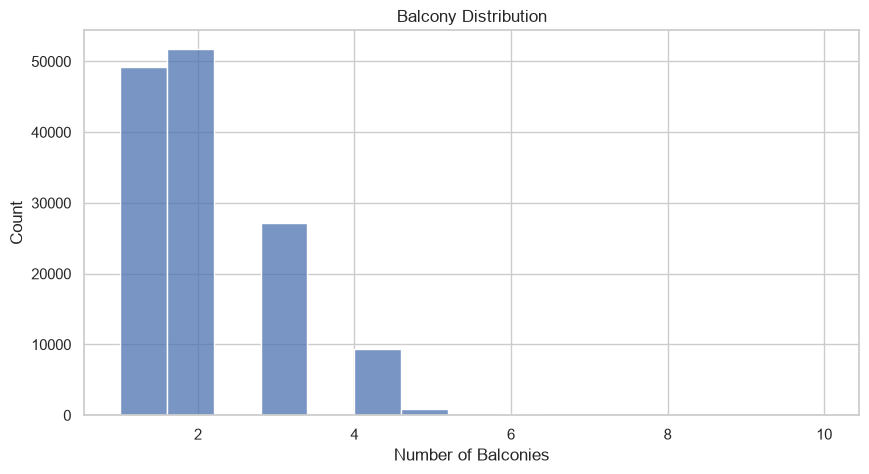

In [58]:
plt.figure(figsize=(10,5))

sns.histplot(df["Balcony"], bins=15)

plt.title("Balcony Distribution")

plt.xlabel("Number of Balconies")

plt.ylabel("Count")

plt.show()

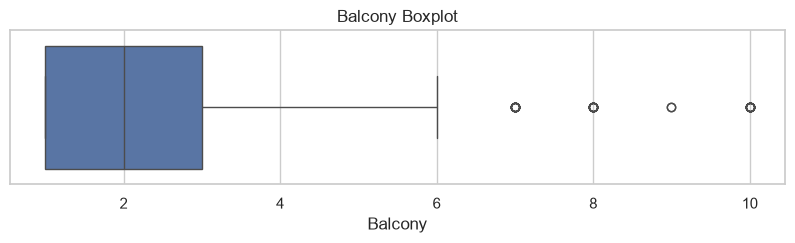

In [59]:
plt.figure(figsize=(10,2))

sns.boxplot(x=df["Balcony"])

plt.title("Balcony Boxplot")

plt.show()

### Frequency of Balcony Values

In [60]:
df["Balcony"].value_counts().sort_index()

Balcony
1.0     49219
2.0     51809
3.0     27111
4.0      9420
5.0       841
6.0       132
7.0        14
8.0        13
9.0         2
10.0       13
Name: count, dtype: int64

### Smallest Balcony Values

In [61]:
df.nsmallest(
    10,
    "Balcony"
)[
    [
        "Title",
        "Balcony",
        "Amount(in rupees)",
        "location"
    ]
]

,Title,Balcony,Amount(in rupees),location
3,1 BHK Ready to Occupy Flat for sale Kasheli,1.0,25 Lac,thane
5,1 BHK Ready to Occupy Flat for sale in Virat A...,1.0,45 Lac,thane
9,3 BHK Ready to Occupy Flat for sale in Pride P...,1.0,1.60 Cr,thane
13,4 BHK Ready to Occupy Flat for sale Hiranandan...,1.0,4.25 Cr,thane
15,2 BHK Ready to Occupy Flat for sale in Puranik...,1.0,90 Lac,thane
19,1 BHK Ready to Occupy Flat for sale Shahad,1.0,35 Lac,thane
23,3 BHK Ready to Occupy Flat for sale in Tierra ...,1.0,1.28 Cr,thane
26,1 BHK Ready to Occupy Flat for sale in Xrbia W...,1.0,24 Lac,thane
29,1 BHK Ready to Occupy Flat for sale in Balaji ...,1.0,47 Lac,thane
30,4 BHK Ready to Occupy Flat for sale in Hiranan...,1.0,3.20 Cr,thane


### Largest Balcony Values

In [62]:
df.nlargest(
    10,
    "Balcony"
)[
    [
        "Title",
        "Balcony",
        "Amount(in rupees)",
        "location"
    ]
]

,Title,Balcony,Amount(in rupees),location
1952,8 BHK Ready to Occupy Flat for sale in Sunteck...,10.0,36.80 Cr,mumbai
15853,10 BHK Ready to Occupy Flat for sale Hsr Layout,10.0,3.80 Cr,bangalore
51023,3 BHK Ready to Occupy Flat for sale in M3M Gol...,10.0,4.16 Cr,gurgaon
51751,4 BHK Ready to Occupy Flat for sale in Pioneer...,10.0,7.50 Cr,gurgaon
82639,3 BHK Ready to Occupy Flat for sale in Balaji ...,10.0,63 Lac,jaipur
114443,8 BHK Ready to Occupy Flat for sale in Sunteck...,10.0,36.80 Cr,mumbai
115771,4 BHK Ready to Occupy Flat for sale Timarpur,10.0,4 Cr,new-delhi
116930,3 BHK Ready to Occupy Flat for sale in Saral A...,10.0,1.75 Cr,new-delhi
147580,3 BHK Ready to Occupy Flat for sale Fatehabad ...,10.0,20 Lac,agra
153451,3 BHK Ready to Occupy Flat for sale in Sikka K...,10.0,1.22 Cr,dehradun


# 35. Balcony Feature Assessment

The Balcony feature was examined to identify missing values, unrealistic observations, and potential outliers.

The feature appears consistent and does not require value correction or outlier removal.

In [63]:
print("No cleaning was applied to the Balcony feature.")

print()

print("Minimum Balconies :", df["Balcony"].min())
print("Maximum Balconies :", df["Balcony"].max())

print()

print("Missing values :", df["Balcony"].isna().sum())
print(
    "Missing (%) :",
    round(df["Balcony"].isna().mean() * 100, 2),
    "%"
)

No cleaning was applied to the Balcony feature.

Minimum Balconies : 1.0
Maximum Balconies : 10.0

Missing values : 48957
Missing (%) : 26.11 %


### Observation

- The Balcony feature contains approximately 26% missing values, which will be handled during the preprocessing stage.

- All observed balcony counts range from 1 to 10 and are considered realistic for residential properties.

- Properties with a large number of balconies correspond to luxury apartments or very large houses and were therefore retained.

- No cleaning or outlier removal was required for this feature.